In [375]:
import pandas as pd

In [376]:
cd = pd.read_csv("olist_customers_dataset.csv") 
gd=pd.read_csv("olist_geolocation_dataset.csv")
ot=pd.read_csv("olist_order_items_dataset.csv")
od=pd.read_csv("olist_orders_dataset.csv")
pyd=pd.read_csv("olist_order_payments_dataset.csv")
ord=pd.read_csv("olist_order_reviews_dataset.csv")
odd=pd.read_csv("olist_orders_dataset.csv")
prd=pd.read_csv("olist_products_dataset.csv")
osd=pd.read_csv("olist_sellers_dataset.csv")
pcn=pd.read_csv("product_category_name_translation.csv")

📊 Business Request: Understand Customer Spending Behavior

In [377]:
odd

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [378]:
ot['revenue'] = ot['price'] + ot['freight_value']
ot

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


In [379]:
# Average order value
order_value = ot.groupby('order_id')['revenue'].sum()
average_order_value = order_value.mean()
print(round(average_order_value, 2))

160.58


In [380]:
# Typical order value
typical_order_value = order_value.median()
print(round(typical_order_value, 2))

105.29


high_value_customers


In [381]:
order_value.reset_index()

,order_id,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,343.40
98662,fffcd46ef2263f404302a634eb57f7eb,386.53
98663,fffce4705a9662cd70adb13d4a31832d,116.85
98664,fffe18544ffabc95dfada21779c9644f,64.71


In [382]:
customer_order=od[['order_id','customer_id']].merge(ot,how='left',on='order_id')

In [383]:
customer_order

,order_id,customer_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62
...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,195.00
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,1.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,271.01
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,220.58
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,220.58


In [384]:
high_value_customers = (
    customer_order
    .groupby(['order_id', 'customer_id'])
    .agg(
        total_revenue=('revenue', 'sum'),
        total_orders=('order_id', 'count'),
        average_order_value=('revenue', 'mean')
    )
    .reset_index()
)

In [385]:
high_value_customers.sort_values(by='total_revenue', ascending=False).head(10)

,order_id,customer_id,total_revenue,total_orders,average_order_value
1471,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,13664.08,8,1708.01
44830,736e1922ae60d0d6a89247b851902527,ec5b2ba62e574342386871631fafd3fc,7274.88,4,1818.72
3156,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,6929.31,1,6929.31
99072,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,6922.21,1,6922.21
95187,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66,1,6726.66
17255,2cc9089445046817a7539d90805e6e5a,05455dfa7cd02f13d132aa7a6a9729c6,6081.54,6,1013.59
65576,a96610ab360d42a2e5335a3998b4718a,df55c14d1476a9a3467f131269c2477f,4950.34,1,4950.34
70098,b4c4b76c642808cbe472a32b86cddc95,e0a2412720e9ea4f26c1ac985f6a7358,4809.44,2,2404.72
9941,199af31afc78c699f0dbf71fb178d4d4,24bbf5fd2f2e1b359ee7de94defc4a15,4764.34,1,4764.34
54793,8dbc85d1447242f3b127dda390d56e19,3d979689f636322c62418b6346b1c6d2,4681.78,1,4681.78


## Is spending consistent?

In [386]:
#Mean vs Median
if average_order_value < typical_order_value:
    print("Spending is fairly consistent")
elif average_order_value > typical_order_value:
    print("A few expensive orders are pulling the average up")
else:
    print("Spending is fairly consistent")

A few expensive orders are pulling the average up


In [387]:
#Standard Deviation
#Do customers have similar average spending habits?
standard_deviation = high_value_customers['average_order_value'].std()
standard_deviation

198.22662837407265

In [388]:
#Is customer spending consistent per order?
customer_standard_deviation = high_value_customers['total_revenue'].std()
customer_standard_deviation 

220.05880401249078

CV	Interpretation
< 25%	Very consistent
25–50%	Fairly consistent
50–100%	High variation
> 100%	Very high variation / highly inconsistent

In [389]:
#Coefficient of Variation (CV)
print((standard_deviation/average_order_value)*100)

123.445973380377


In [390]:
#Coefficient of Variation (CV)
print((standard_deviation/average_order_value)*100)

123.445973380377


Conclution:
Customer spending is highly inconsistent. The coefficient of variation is 123%, meaning the variation in order values exceeds the average order value. This suggests that while many customers place relatively small orders, a smaller group of customers places much larger orders, resulting in a wide spread of spending.

📊 Business Request: Identify Unusual Transactions

In [391]:
import matplotlib.pyplot as plt
import seaborn as sns

In [392]:
high_value_customers

,order_id,customer_id,total_revenue,total_orders,average_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,72.19,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,259.83,1,259.83
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,216.87,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,25.78,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,218.04,1,218.04
...,...,...,...,...,...
99436,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,343.40,1,343.40
99437,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,386.53,1,386.53
99438,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,116.85,1,116.85
99439,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,64.71,1,64.71


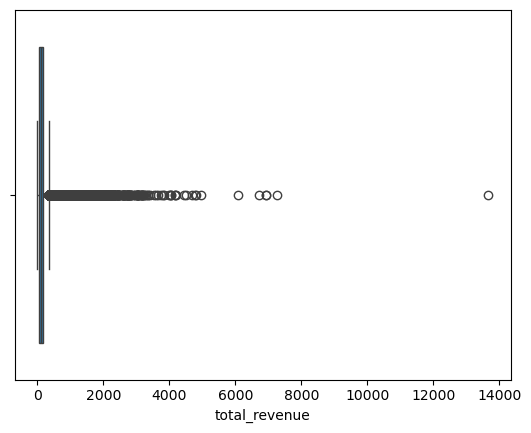

In [393]:
sns.boxplot(x=high_value_customers['total_revenue'])
plt.show()

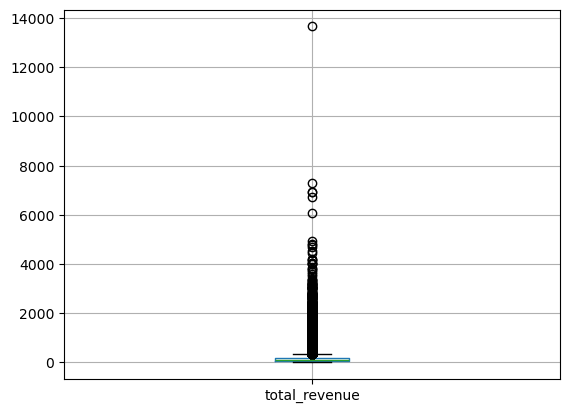

In [394]:
high_value_customers.boxplot(column='total_revenue')
plt.show()

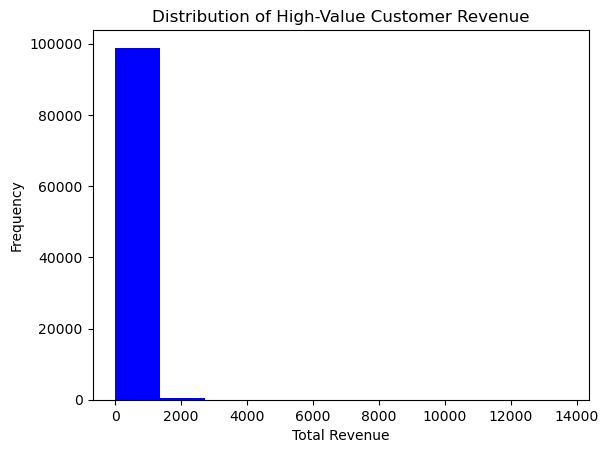

In [395]:
plt.hist(high_value_customers['total_revenue'],color='blue')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')
plt.title('Distribution of High-Value Customer Revenue')
plt.show()

Histogram conlusiton: The first bar (left side) is extremely tall, while almost all other bars are very small.

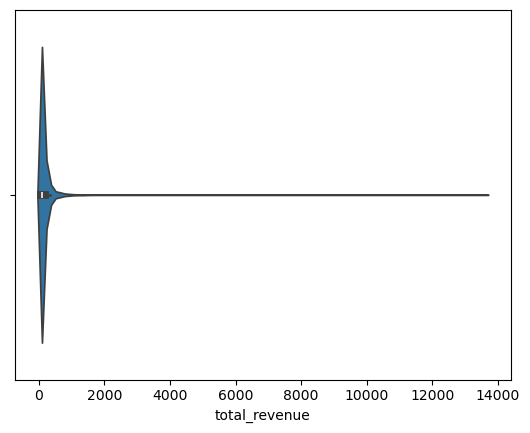

In [396]:
sns.violinplot(x=high_value_customers['total_revenue'])
plt.show()

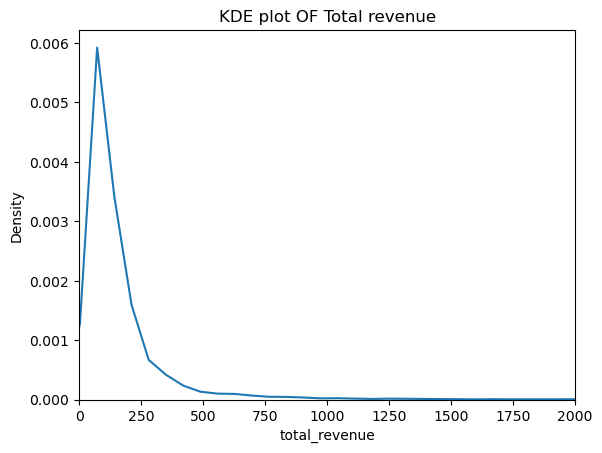

In [397]:
sns.kdeplot(data=high_value_customers['total_revenue'])
plt.title("KDE plot OF Total revenue")
plt.xlim(0,2000)
plt.show()


Extremely right-skewed

### 📊 Business Request: Identify Relationships Between Variables

In [398]:
''' Questions
-Does higher payment value lead to higher review scores?
-Does longer delivery time reduce customer ratings?
-Does freight cost increase with product weight? '''

' Questions\n-Does higher payment value lead to higher review scores?\n-Does longer delivery time reduce customer ratings?\n-Does freight cost increase with product weight? '

In [399]:
ot

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


In [400]:
review_data = (
    ot.groupby(['order_id', 'product_id'])
      .agg(total=('price', 'sum'))
      .reset_index()
      .merge(prd[['product_id', 'product_category_name']], on='product_id', how='left')
)

In [401]:
review_data=review_data.merge(ord[['order_id', 'review_score']], on='order_id', how='left')

In [402]:
review_data

,order_id,product_id,total,product_category_name,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao,5.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumaria,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim,5.0
...,...,...,...,...,...
103022,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,299.99,utilidades_domesticas,5.0
103023,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,350.00,informatica_acessorios,5.0
103024,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,99.90,esporte_lazer,5.0
103025,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,55.99,informatica_acessorios,5.0


In [403]:
pivot=pd.pivot_table(
    review_data,
    index='product_category_name',
    columns='review_score',
    values='order_id',
    aggfunc='count',
    fill_value=0
)

In [404]:
new = (
    review_data.groupby("product_category_name")
    .agg(
        review_count=("review_score", "count"),
        average_review=("review_score", "mean"),
        total_sales=("total", "sum"),
        average_price=("total", "mean")
    )
    .reset_index()
)

In [405]:
new

,product_category_name,review_count,average_review,total_sales,average_price
0,agro_industria_e_comercio,183,4.027322,72530.47,396.341366
1,alimentos,448,4.270089,29393.41,64.886115
2,alimentos_bebidas,235,4.395745,15270.47,64.705381
3,artes,200,4.025000,24202.64,119.815050
4,artes_e_artesanato,24,4.125000,1814.01,75.583750
...,...,...,...,...,...
68,sinalizacao_e_seguranca,141,4.092199,21509.23,150.414196
69,tablets_impressao_imagem,77,4.155844,7528.41,95.296329
70,telefonia,4259,3.984269,323839.40,75.451864
71,telefonia_fixa,215,3.902326,59622.99,273.499954


In [406]:
corr=new.corr(numeric_only=True)

In [407]:
corr



,review_count,average_review,total_sales,average_price
review_count,1.000000,0.032421,0.957486,-0.106046
average_review,0.032421,1.000000,0.034783,-0.019335
total_sales,0.957486,0.034783,1.000000,0.018028
average_price,-0.106046,-0.019335,0.018028,1.000000


<Axes: >

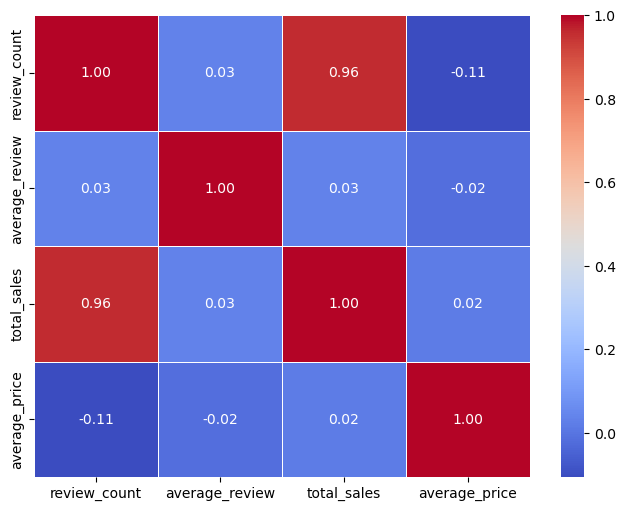

In [408]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)

'''
Correlation	Meaning
+1	Perfect positive relationship
0.7 to 0.9	Strong positive
0.3 to 0.7	Moderate positive
0	No relationship
-0.3 to -0.7	Moderate negative
-0.7 to -1	Strong negative
'''

### high value data frame

In [409]:
corr=high_value_customers.corr(numeric_only=True)

In [410]:
corr

,total_revenue,total_orders,average_order_value
total_revenue,1.000000,0.190205,0.924475
total_orders,0.190205,1.000000,-0.058466
average_order_value,0.924475,-0.058466,1.000000


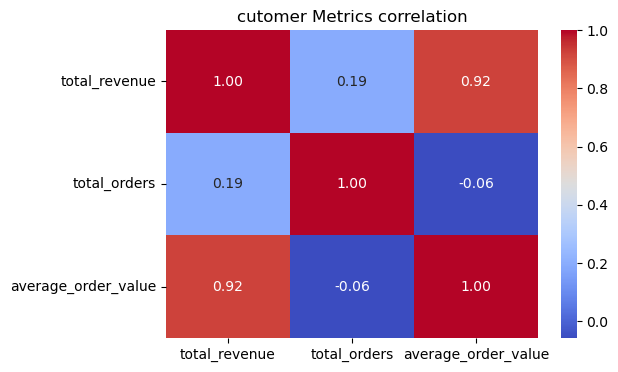

In [411]:
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("cutomer Metrics correlation")
plt.show()

Does longer delivery time reduce customer ratings?

In [412]:
order_review=odd.copy

In [413]:
order_review()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [414]:
# Convert timestamp columns to datetime
odd['order_purchase_timestamp'] = pd.to_datetime(odd['order_purchase_timestamp'])
odd['order_estimated_delivery_date'] = pd.to_datetime(odd['order_estimated_delivery_date'])

# Calculate delivery time in days
odd['estimated_delivery_days'] = (odd['order_estimated_delivery_date'] - odd['order_purchase_timestamp']).dt.days

# Display the result
order_review_time=odd[['order_id', 'order_purchase_timestamp', 'order_estimated_delivery_date', 'estimated_delivery_days']].head(10)

In [415]:
ord

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [416]:
order_review_time = order_review_time.merge(
    ord[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

In [417]:
order_review_time 

,order_id,order_purchase_timestamp,order_estimated_delivery_date,estimated_delivery_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-18,15,4
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-13,19,4
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-09-04,26,5
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-15,26,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-26,12,5
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,2017-08-01,22,4
6,136cce7faa42fdb2cefd53fdc79a6098,2017-04-11 12:22:08,2017-05-09,27,2
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,2017-06-07,21,5
8,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,2017-03-06,41,1
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,2017-08-23,24,5


In [418]:
corr_review =order_review_time.corr(numeric_only=True)

<Axes: >

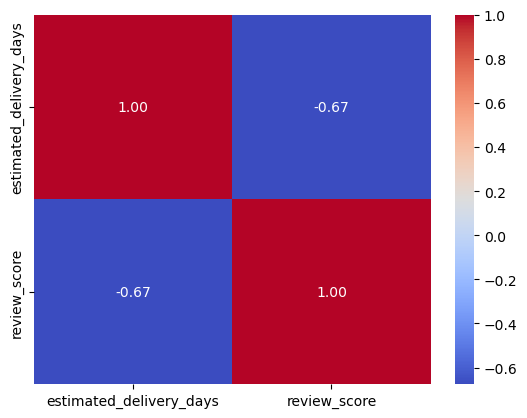

In [419]:
sns.heatmap(corr_review ,annot=True,cmap='coolwarm',fmt='.2f')

In [420]:
order_review_time['delivery_group'] = pd.cut(
    order_review_time['estimated_delivery_days'],
    bins=[0,5,10,15,20,30,50],
    labels=['1-5','6-10','11-15','16-20','21-30','30+']
)

<Axes: xlabel='delivery_group', ylabel='review_score'>

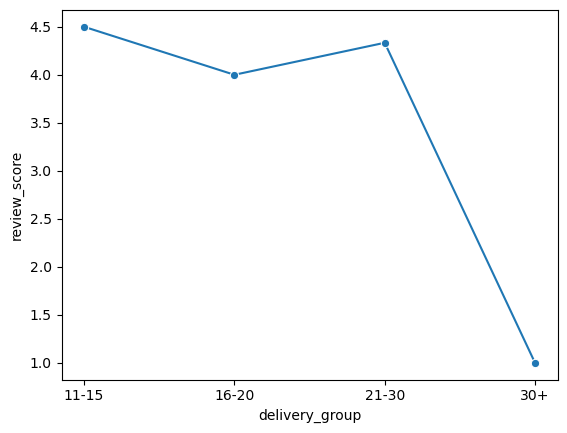

In [421]:
sns.lineplot(
    data=avg,
    x='delivery_group',
    y='review_score',
    marker='o'
)

In [422]:
avg = (order_review_time
       .groupby('delivery_group')['review_score']
       .mean()
       .reset_index())

/var/folders/_x/_89f24qx7r132r9268w_gw0r0000gn/T/ipykernel_32729/1021251528.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('delivery_group')['review_score']


<Axes: xlabel='delivery_group', ylabel='review_score'>

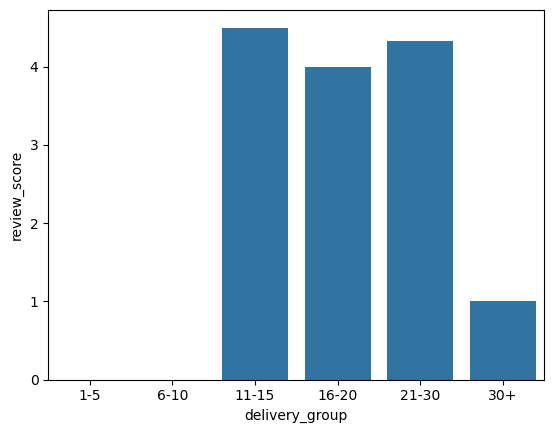

In [423]:
sns.barplot(data=avg,
            x='delivery_group',
            y='review_score')

Conclusion: Less delivery time gives higher ratings

📊 Business Request: Identify Unusual Transactions
Objective

In [424]:
high_value_customers

,order_id,customer_id,total_revenue,total_orders,average_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,72.19,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,259.83,1,259.83
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,216.87,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,25.78,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,218.04,1,218.04
...,...,...,...,...,...
99436,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,343.40,1,343.40
99437,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,386.53,1,386.53
99438,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,116.85,1,116.85
99439,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,64.71,1,64.71


<Axes: >

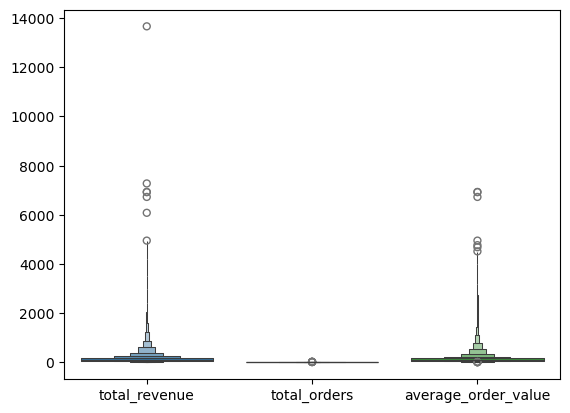

In [425]:
sns.boxenplot(high_value_customers)

In [426]:
#Are there extremely expensive orders?
high_value_customers[high_value_customers['total_revenue']>12000]

,order_id,customer_id,total_revenue,total_orders,average_order_value
1471,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,13664.08,8,1708.01


In [427]:
ot

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


<Axes: ylabel='freight_value'>

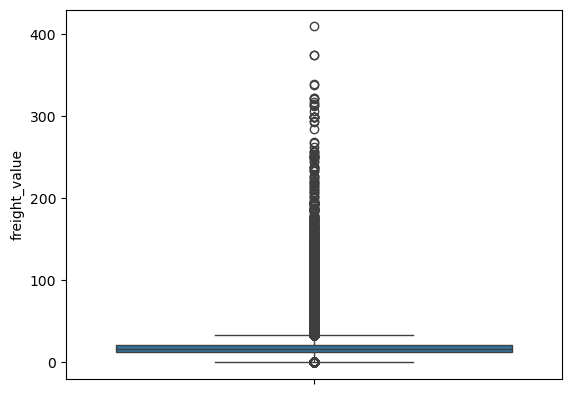

In [428]:
sns.boxplot(ot['freight_value'])

In [429]:
Are some products significantly heavier than others?

Object `others` not found.


<Axes: ylabel='product_weight_g'>

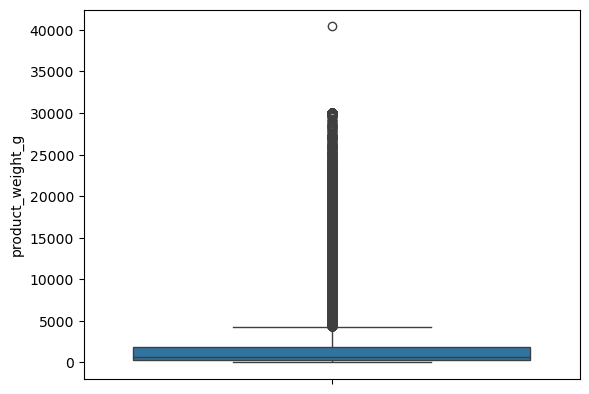

In [430]:
sns.boxplot(prd['product_weight_g'])

In [431]:
#Are some products significantly heavier than others?
products_significantly_heavier=prd[prd['product_weight_g']>40000]

In [432]:
print(products_significantly_heavier['product_category_name'])

25166    cama_mesa_banho
Name: product_category_name, dtype: object


## 📊 Business Request: Analyze Business Trends

In [433]:
odd['Deliver_month'] = pd.to_datetime(
    odd['order_delivered_carrier_date']
).dt.month_name()

In [434]:
odd['year'] = pd.to_datetime(
    odd['order_delivered_carrier_date']
).dt.year

In [435]:
order=odd.merge(ot[['order_id','price']],on='order_id',how='left')

In [436]:
order

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,estimated_delivery_days,Deliver_month,year,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,15,October,2017.0,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,19,July,2018.0,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,26,August,2018.0,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,26,November,2017.0,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,12,February,2018.0,19.90
...,...,...,...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,23,February,2018.0,174.90
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,30,August,2017.0,205.99
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,37,January,2018.0,179.99
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,37,January,2018.0,179.99


In [437]:
order_summary = (
    order.groupby(['year', 'Deliver_month'])['price']
         .sum()
         .reset_index()
)

In [438]:
order_summary.shape

(24, 3)

In [439]:
order_summary['Date'] = pd.to_datetime(
    order_summary['Deliver_month'] + ' ' + order_summary['year'].astype(int).astype(str),
    format='%B %Y'
)

In [440]:
order_summary = order_summary.sort_values('Date')

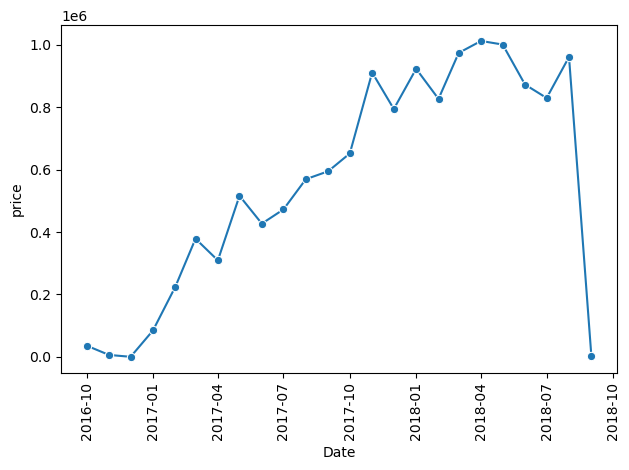

In [441]:
sns.lineplot(data=order_summary, x='Date', y='price', marker='o')
plt.xticks(rotation=90)
plt.tight_layout()
plt.xticks(rotation=90)
plt.tight_layout()

In [442]:
Monthly_Customers = (
    order.groupby(['year', 'Deliver_month'])['customer_id']
         .count()
         .reset_index()
)

In [443]:
Monthly_Customers['Date'] = pd.to_datetime(
    Monthly_Customers['Deliver_month'] + ' ' + Monthly_Customers['year'].astype(int).astype(str),
    format='%B %Y'
)

In [444]:
order_summary['Month_Year'] = order_summary['Date'].dt.strftime('%B %Y')

In [445]:
Monthly_Customers.sort_values(by='Date')

,year,Deliver_month,customer_id,Date
2,2016.0,October,296,2016-10-01
1,2016.0,November,36,2016-11-01
0,2016.0,December,2,2016-12-01
7,2017.0,January,726,2017-01-01
6,2017.0,February,1719,2017-02-01
10,2017.0,March,3105,2017-03-01
3,2017.0,April,2388,2017-04-01
11,2017.0,May,4179,2017-05-01
9,2017.0,June,3643,2017-06-01
8,2017.0,July,4200,2017-07-01


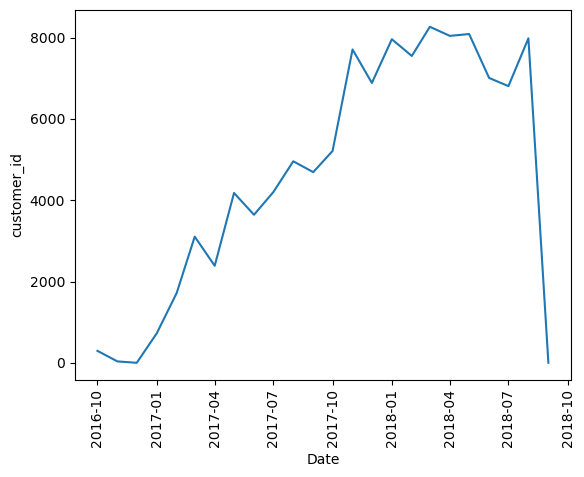

In [446]:
sns.lineplot(data=Monthly_Customers,y='customer_id',x='Date')
plt.xticks(rotation=90)
plt.show()

Monthly customers increased steadily from 2016 to 2018, showing strong business growth. Customer count peaked in 2018, while the sharp drop in September 2018 is likely due to incomplete data rather than an actual decline.

### 📊 Business Request: Understand Category Performance
Objective

In [447]:
prd.sample()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
29316,fb0467f650186a474da44003e623a3c4,telefonia,43.0,299.0,3.0,200.0,16.0,4.0,11.0


In [448]:
pcn.sample()

,product_category_name,product_category_name_english
26,moveis_cozinha_area_de_servico_jantar_e_jardim,kitchen_dining_laundry_garden_furniture


In [449]:
category=pcn.merge(prd[['product_category_name','product_id']],on='product_category_name',how='left')

In [450]:
category_revenue=ot.merge(category[['product_id','product_category_name_english']],on='product_id',how='left')

In [451]:
final_category=category_revenue.groupby('product_category_name_english')['revenue'].sum().reset_index()

In [452]:
#category has the highest revenue
final_category[final_category['revenue'] == final_category['revenue'].max()]

,product_category_name_english,revenue
43,health_beauty,1441248.07


In [453]:
#
final_category[final_category['revenue'] == final_category['revenue'].min()]

,product_category_name_english,revenue
61,security_and_services,324.51


In [454]:
#category has the highest ratings

In [455]:
review_data

,order_id,product_id,total,product_category_name,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao,5.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumaria,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim,5.0
...,...,...,...,...,...
103022,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,299.99,utilidades_domesticas,5.0
103023,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,350.00,informatica_acessorios,5.0
103024,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,99.90,esporte_lazer,5.0
103025,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,55.99,informatica_acessorios,5.0


In [456]:
avg_rating=review_data.groupby('product_category_name')['review_score'].mean().reset_index()


In [457]:
avg_rating

,product_category_name,review_score
0,agro_industria_e_comercio,4.027322
1,alimentos,4.270089
2,alimentos_bebidas,4.395745
3,artes,4.025000
4,artes_e_artesanato,4.125000
...,...,...
68,sinalizacao_e_seguranca,4.092199
69,tablets_impressao_imagem,4.155844
70,telefonia,3.984269
71,telefonia_fixa,3.902326


In [458]:
avg_rating=avg_rating.merge(pcn[['product_category_name','product_category_name_english']],on='product_category_name',how='left')

In [459]:
final_category= final_category.merge(avg_rating[['product_category_name_english','review_score']],on='product_category_name_english',how='left')

In [460]:
 #ategory has the highest rating
 final_category[final_category['review_score']==final_category['review_score'].max()]

,product_category_name_english,revenue,review_score
11,cds_dvds_musicals,954.99,4.666667


In [461]:
#category needs improvement
final_category[final_category['review_score']==final_category['review_score'].min()]

,product_category_name_english,revenue,review_score
61,security_and_services,324.51,2.5


### ❓ KEY BUSINESS QUESTIONS

Q1. What is the average customer review score? How is it distributed?

In [462]:
#Average customer review score
print(round(review_data['review_score'].mean(),1))

4.1


In [463]:
#Descriptive statistics
review_data['review_score'].describe()

count    102230.000000
mean          4.076367
std           1.354024
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64

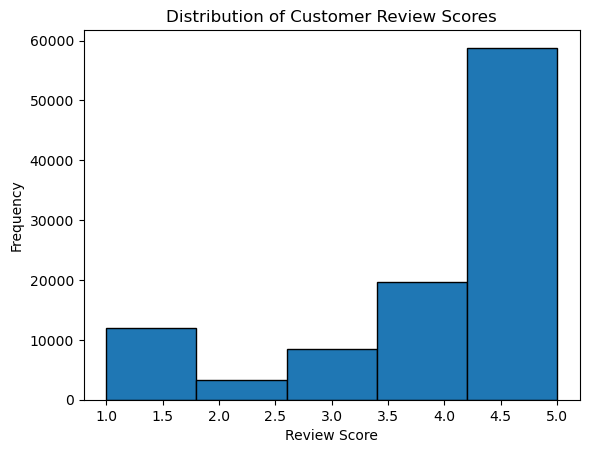

In [464]:
#Distribution plot (Histogram)
plt.hist(review_data['review_score'],bins=5,edgecolor='black')
plt.title('Distribution of Customer Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.show()

In [465]:
#Count of each review score
review_data['review_score'].value_counts().sort_index()


review_score
1.0    11908
2.0     3378
3.0     8525
4.0    19607
5.0    58812
Name: count, dtype: int64

Q2: What factors most influence customer satisfaction (review score)?

In [466]:
print(review_data['review_score'].corr(review_data['total']))

-0.025020998827984527


In [467]:
corr=review_data.corr(numeric_only=True)

<Axes: >

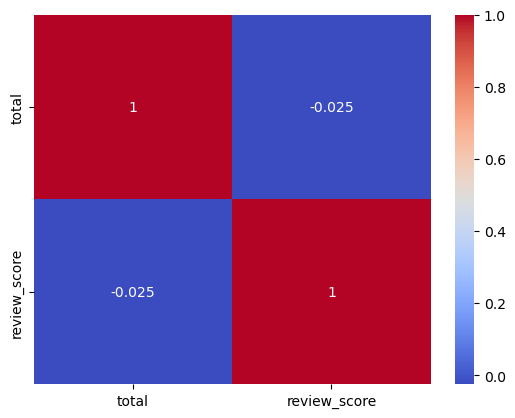

In [468]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

Q3: What percentage of customers are satisfied (≥4 stars) vs unsatisfied (<3 stars)?

In [469]:
final_category

,product_category_name_english,revenue,review_score
0,agro_industry_and_commerce,78374.07,4.027322
1,air_conditioning,61774.19,4.032000
2,art,28247.81,4.025000
3,arts_and_craftmanship,2184.14,4.125000
4,audio,56398.94,3.827586
...,...,...,...
66,stationery,277741.71,4.228403
67,tablets_printing_image,8754.61,4.155844
68,telephony,394883.32,3.984269
69,toys,561372.55,4.179818


In [470]:
import numpy as np 
final_category['status']=np.where(final_category['review_score'] >=4,'satisfied','Unstatisfied')

In [471]:
(final_category['status'].value_counts(normalize=True)*100).round(2)

status
satisfied       76.06
Unstatisfied    23.94
Name: proportion, dtype: float64

Q4: Which product categories have highest/lowest review scores?

In [472]:
avg_review=review_data.groupby('product_category_name')['review_score'].mean().reset_index()

In [473]:
avg_review[avg_review['review_score'] == avg_review['review_score'].min()]

,product_category_name,review_score
67,seguros_e_servicos,2.5


In [474]:
avg_review[avg_review['review_score'] == avg_review['review_score'].max()]

,product_category_name,review_score
17,cds_dvds_musicais,4.666667


Q5: How does delivery time impact customer satisfaction?

In [475]:
corr_review=order_review_time.corr(numeric_only=True)

<Axes: xlabel='review_score', ylabel='estimated_delivery_days'>

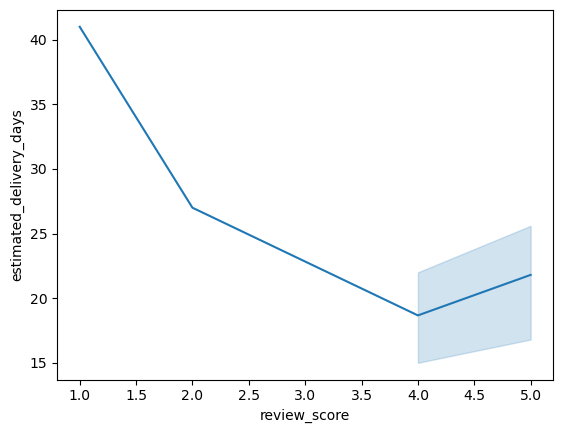

In [476]:
sns.lineplot(
    data=order_review_time,
    x='review_score',
    y='estimated_delivery_days'
)

<Axes: >

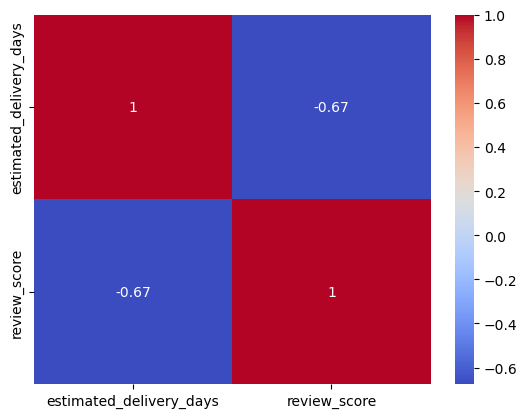

In [477]:
sns.heatmap(corr_review,annot=True,cmap='coolwarm')

2️⃣ REGIONAL PERFORMANCE

In [478]:
#Q6: Which states/regions have most orders? Show top 10?


In [479]:
cd.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [480]:
odd.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,estimated_delivery_days,Deliver_month,year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,15,October,2017.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,19,July,2018.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,26,August,2018.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,26,November,2017.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,12,February,2018.0


In [481]:
customer_city=odd[['order_id','customer_id']].merge(cd[['customer_id','customer_city','customer_state']],on='customer_id',how='left')

In [482]:
customer_city

,order_id,customer_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,japuiba,RJ


In [483]:
customer_city= customer_city.merge(ot[['order_id','revenue']],on='order_id',how='left')

In [484]:
customer_city.columns

Index(['order_id', 'customer_id', 'customer_city', 'customer_state',
       'revenue'],
      dtype='object')

In [485]:
customer_state_group=customer_city.groupby('customer_state')['revenue'].sum().reset_index().sort_values(by='revenue')

In [486]:
customer_state_group

,customer_state,revenue
21,RR,10064.62
3,AP,16262.80
0,AC,19669.70
2,AM,27835.73
20,RO,57558.02
26,TO,61354.42
24,SE,73032.32
1,AL,96229.40
19,RN,101895.08
16,PI,108132.28


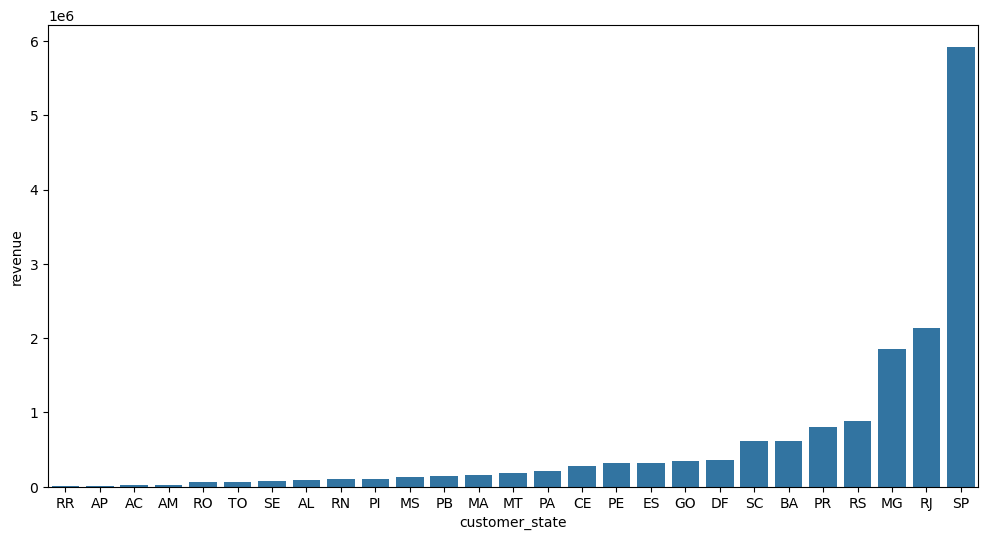

In [487]:
plt.figure(figsize=(12, 6))
sns.barplot(data=customer_state_group, x='customer_state', y='revenue')
plt.show()

In [488]:
#Q7: Which regions have highest average review scores?

In [497]:
review_data= review_data.merge(customer_city[['order_id','customer_state']],on='order_id',how='left')

In [506]:
review_data

,order_id,product_id,total,product_category_name,review_score,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff,5.0,RJ
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop,4.0,SP
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao,5.0,MG
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumaria,4.0,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim,5.0,SP
...,...,...,...,...,...,...
123446,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,299.99,utilidades_domesticas,5.0,MA
123447,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,350.00,informatica_acessorios,5.0,PR
123448,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,99.90,esporte_lazer,5.0,SP
123449,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,55.99,informatica_acessorios,5.0,SP


In [507]:
review_group=review_data.groupby('customer_state').agg(avg_review=('review_score',sum)).round(2).reset_index()

/var/folders/_x/_89f24qx7r132r9268w_gw0r0000gn/T/ipykernel_32729/3390271065.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  review_group=review_data.groupby('customer_state').agg(avg_review=('review_score',sum)).round(2).reset_index()


In [509]:
review_group.sort_values(by='avg_review',ascending=False).head(1)

,customer_state,avg_review
25,SP,211033.0


In [ ]:
#Q8: What's the delivery time difference between top regions?

In [572]:
esitmate_days=review_data.merge(odd[['order_id','estimated_delivery_days']],on='order_id',how='left')

In [573]:
esitmate_days

,order_id,product_id,total,product_category_name,review_score,customer_state,estimated_delivery_days
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff,5.0,RJ,15
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop,4.0,SP,18
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao,5.0,MG,21
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumaria,4.0,SP,11
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim,5.0,SP,40
...,...,...,...,...,...,...,...
123446,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,299.99,utilidades_domesticas,5.0,MA,24
123447,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,350.00,informatica_acessorios,5.0,PR,17
123448,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,99.90,esporte_lazer,5.0,SP,17
123449,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,55.99,informatica_acessorios,5.0,SP,10


In [574]:
esitmate_days['estimated_delivery_days'].max()-esitmate_days['estimated_delivery_days'].min()

153

In [575]:
esitmate_days.describe()

,total,review_score,estimated_delivery_days
count,123451.000000,122383.000000,123451.000000
mean,140.307409,3.969563,23.599679
std,242.317699,1.431527,8.961030
min,0.850000,1.000000,2.000000
25%,45.000000,3.000000,18.000000
50%,84.990000,5.000000,23.000000
75%,149.900000,5.000000,28.000000
max,13440.000000,5.000000,155.000000


In [524]:
#Q10: Which regions have best delivery accuracy?

In [576]:
best_accuracy_region = (
    od.merge(
        cd[['customer_id', 'customer_state']],
        on='customer_id',
        how='left'
    )
)

In [577]:
best_accuracy_region['order_delivered_customer_date'] = pd.to_datetime(
    best_accuracy_region['order_delivered_customer_date']
)

best_accuracy_region['order_estimated_delivery_date'] = pd.to_datetime(
    best_accuracy_region['order_estimated_delivery_date']
)

In [578]:
best_accuracy_region['on_time_delivery'] = (
    best_accuracy_region['order_delivered_customer_date']
    <=
    best_accuracy_region['order_estimated_delivery_date']
)

In [579]:
delivery_accuracy = (
    best_accuracy_region
    .groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        on_time_orders=('on_time_delivery', 'sum')
    )
    .reset_index()
)

delivery_accuracy['delivery_accuracy_%'] = (
    delivery_accuracy['on_time_orders']
    / delivery_accuracy['total_orders']
    * 100
).round(2)

In [591]:
delivery_accuracy[delivery_accuracy['delivery_accuracy_%'] == delivery_accuracy['delivery_accuracy_%'].max()]

,customer_state,total_orders,on_time_orders,delivery_accuracy_%
0,AC,81,77,95.06
